In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()

invoice_path = ROOT / "artifacts" / "training_pipeline_invoice_v1" / "predictions_valid.csv"
oc_path = ROOT / "artifacts" / "training_pipeline_oc_v1" / "predictions_valid.csv"

invoice_df = pd.read_csv(invoice_path)
oc_df = pd.read_csv(oc_path)

invoice_df["invoice_date"] = pd.to_datetime(invoice_df["invoice_date"])
oc_df["invoice_date"] = pd.to_datetime(oc_df["invoice_date"])

print("invoice_df:", invoice_df.shape)
print("oc_df:", oc_df.shape)

invoice_df.head()

invoice_df: (154943, 5)
oc_df: (154943, 5)


,store_id,invoice_date,actual,pred,abs_error
0,79609,2022-01-02,37.0,29.682724,7.317276
1,79609,2022-01-03,60.0,53.763042,6.236958
2,79609,2022-01-04,62.0,50.616783,11.383217
3,79609,2022-01-05,52.0,53.672762,1.672762
4,79609,2022-01-06,16.0,38.097580,22.097580


In [2]:
def add_error_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["error"] = out["pred"] - out["actual"]              # signed error
    out["abs_error"] = (out["pred"] - out["actual"]).abs()  # absolute error
    out["month"] = out["invoice_date"].dt.month
    return out

invoice_df = add_error_columns(invoice_df)
oc_df = add_error_columns(oc_df)

invoice_df[["store_id", "invoice_date", "actual", "pred", "error", "abs_error"]].head()

,store_id,invoice_date,actual,pred,error,abs_error
0,79609,2022-01-02,37.0,29.682724,-7.317276,7.317276
1,79609,2022-01-03,60.0,53.763042,-6.236958,6.236958
2,79609,2022-01-04,62.0,50.616783,-11.383217,11.383217
3,79609,2022-01-05,52.0,53.672762,1.672762,1.672762
4,79609,2022-01-06,16.0,38.097580,22.097580,22.097580


In [3]:
def error_by_store(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby("store_id")
        .agg(
            n_days=("store_id", "size"),
            mean_actual=("actual", "mean"),
            mean_pred=("pred", "mean"),
            mae=("abs_error", "mean"),
            bias=("error", "mean"),
        )
        .sort_values("mae", ascending=False)
        .reset_index()
    )

invoice_store = error_by_store(invoice_df)
oc_store = error_by_store(oc_df)

print("Worst invoice_count stores by MAE:")
display(invoice_store.head(10))

print("Worst oc_count stores by MAE:")
display(oc_store.head(10))

Worst invoice_count stores by MAE:


,store_id,n_days,mean_actual,mean_pred,mae,bias
0,611652,358,128.125698,123.113008,22.211873,-5.012690
1,614420,358,74.427374,74.072854,11.921228,-0.354520
2,614366,358,59.773743,57.379780,11.821826,-2.393963
3,614414,358,94.983240,93.451961,11.762573,-1.531279
4,99215,354,61.963277,62.130430,11.425599,0.167153
5,615286,358,82.932961,82.875181,11.093108,-0.057780
6,231320,358,96.229050,94.288330,10.812314,-1.940720
7,615287,358,108.064246,105.256351,10.791376,-2.807895
8,615212,358,102.217877,100.208121,10.489208,-2.009756
9,84321,357,88.044818,87.163181,10.394753,-0.881637


Worst oc_count stores by MAE:


,store_id,n_days,mean_actual,mean_pred,mae,bias
0,231320,358,91.008380,87.984594,11.043956,-3.023786
1,99215,354,58.107345,56.022859,11.023930,-2.084485
2,611652,358,46.664804,37.000791,10.578907,-9.664013
3,230586,358,80.846369,76.718827,9.946073,-4.127542
4,608890,357,83.240896,78.412977,9.776123,-4.827919
5,255712,358,65.019553,61.154753,9.703737,-3.864800
6,84321,357,78.316527,75.577372,9.664972,-2.739155
7,86765,357,80.170868,76.172461,9.506444,-3.998408
8,100510,358,80.896648,78.069549,9.435668,-2.827099
9,232128,358,71.069832,72.231881,8.945956,1.162049


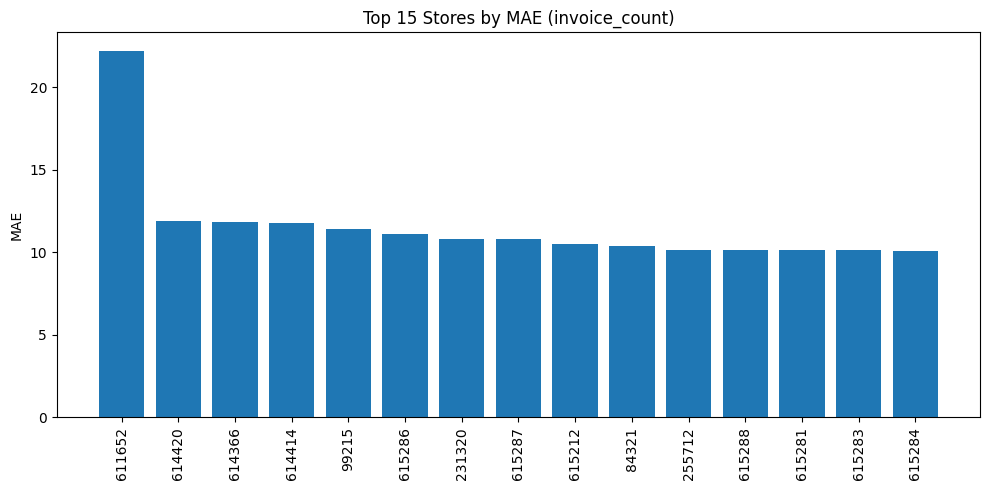

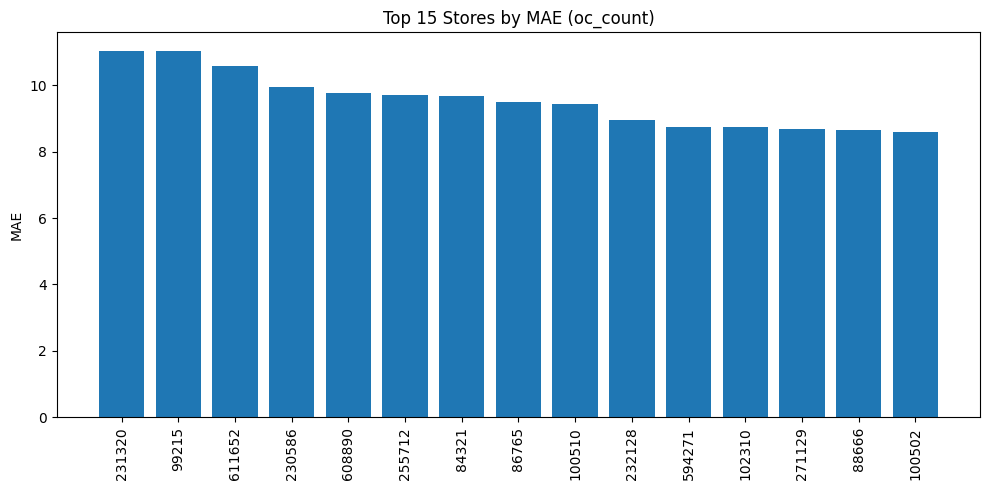

In [4]:
top_n = 15

plt.figure(figsize=(10, 5))
plt.bar(invoice_store["store_id"].astype(str).head(top_n), invoice_store["mae"].head(top_n))
plt.xticks(rotation=90)
plt.title("Top 15 Stores by MAE (invoice_count)")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(oc_store["store_id"].astype(str).head(top_n), oc_store["mae"].head(top_n))
plt.xticks(rotation=90)
plt.title("Top 15 Stores by MAE (oc_count)")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

In [5]:
def error_by_month(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby("month")
        .agg(
            n_days=("month", "size"),
            mean_actual=("actual", "mean"),
            mae=("abs_error", "mean"),
            bias=("error", "mean"),
        )
        .reset_index()
        .sort_values("month")
    )

invoice_month = error_by_month(invoice_df)
oc_month = error_by_month(oc_df)

display(invoice_month)
display(oc_month)

,month,n_days,mean_actual,mae,bias
0,1,12928,50.205910,6.939561,-0.060087
1,2,12072,50.081428,7.349679,-0.054070
2,3,13460,53.121100,6.285103,-0.673144
3,4,12594,52.070669,6.095721,-0.415012
4,5,12961,52.669624,6.362055,-0.064663
5,6,13006,54.906428,6.320679,0.119257
6,7,12934,55.115046,6.526289,-0.129649
7,8,13431,53.498176,6.184478,-0.163586
8,9,12587,54.698419,6.374087,-0.584582
9,10,13400,52.792090,6.020028,0.219436


,month,n_days,mean_actual,mae,bias
0,1,12928,43.040532,6.495180,-0.334625
1,2,12072,43.258284,6.862121,-0.596762
2,3,13460,46.188113,5.876257,-0.784896
3,4,12594,45.294823,5.640047,-0.430900
4,5,12961,45.861816,5.962866,-0.049990
5,6,13006,47.949639,5.908959,-0.125044
6,7,12934,48.086748,6.056974,-0.206340
7,8,13431,46.622887,5.689995,-0.077462
8,9,12587,47.969254,6.008429,-0.697382
9,10,13400,46.279104,5.633350,-0.223385


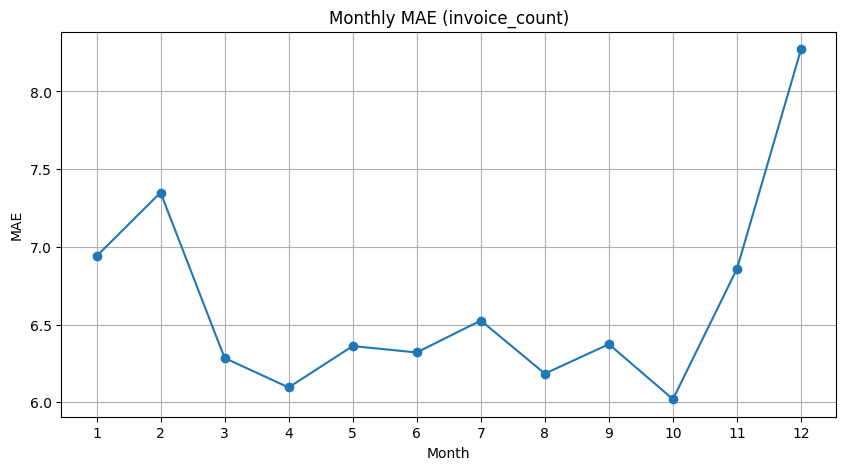

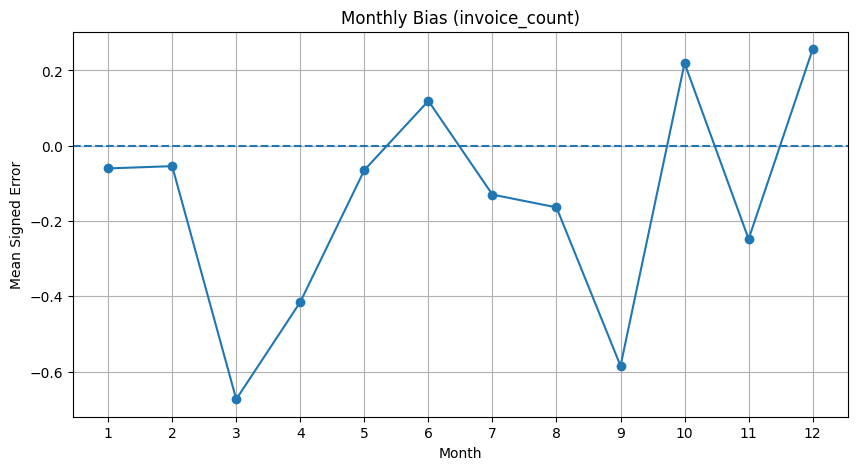

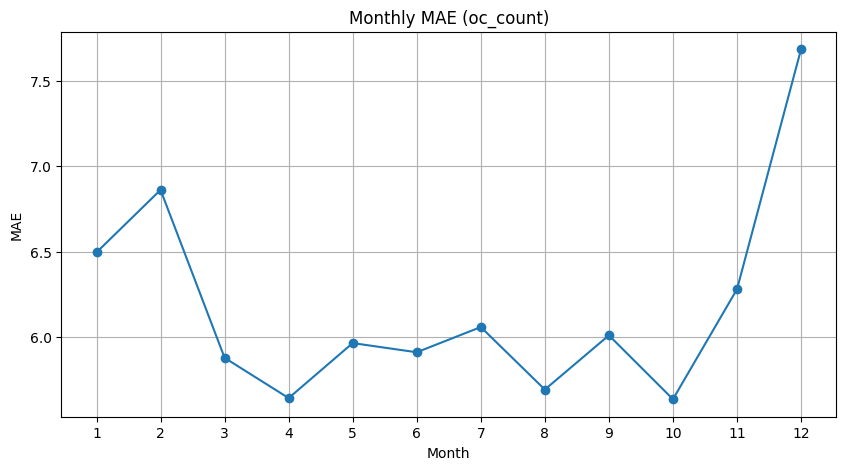

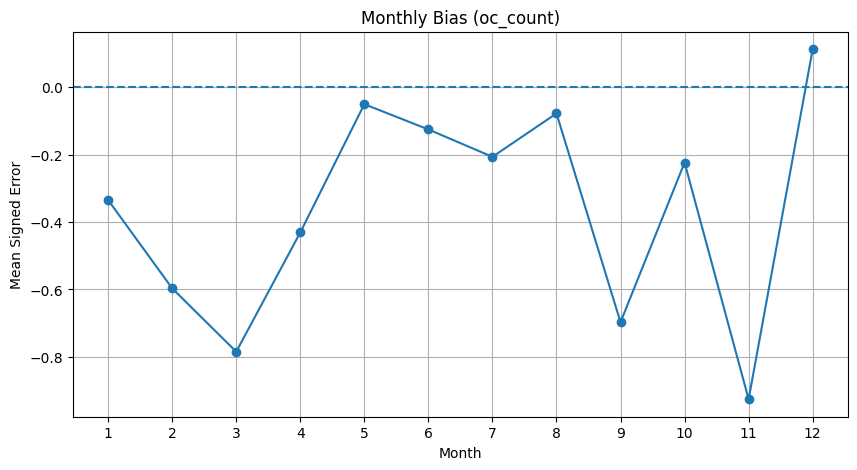

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(invoice_month["month"], invoice_month["mae"], marker="o")
plt.title("Monthly MAE (invoice_count)")
plt.xlabel("Month")
plt.ylabel("MAE")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(invoice_month["month"], invoice_month["bias"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("Monthly Bias (invoice_count)")
plt.xlabel("Month")
plt.ylabel("Mean Signed Error")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(oc_month["month"], oc_month["mae"], marker="o")
plt.title("Monthly MAE (oc_count)")
plt.xlabel("Month")
plt.ylabel("MAE")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(oc_month["month"], oc_month["bias"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("Monthly Bias (oc_count)")
plt.xlabel("Month")
plt.ylabel("Mean Signed Error")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

In [7]:
def add_volume_bucket(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    store_avg = out.groupby("store_id")["actual"].mean().rename("store_avg_actual")
    out = out.merge(store_avg, on="store_id", how="left")
    out["volume_bucket"] = pd.qcut(
        out["store_avg_actual"],
        q=4,
        labels=["Low", "Medium", "High", "Very High"],
        duplicates="drop"
    )
    return out

invoice_df = add_volume_bucket(invoice_df)
oc_df = add_volume_bucket(oc_df)

In [8]:
def error_by_volume_bucket(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby("volume_bucket")
        .agg(
            n_rows=("volume_bucket", "size"),
            mean_actual=("actual", "mean"),
            mae=("abs_error", "mean"),
            bias=("error", "mean"),
        )
        .reset_index()
    )

invoice_volume = error_by_volume_bucket(invoice_df)
oc_volume = error_by_volume_bucket(oc_df)

display(invoice_volume)
display(oc_volume)

/var/folders/tg/304lj0vs4yn7768vztr026j80000gn/T/ipykernel_90170/4228229534.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("volume_bucket")
/var/folders/tg/304lj0vs4yn7768vztr026j80000gn/T/ipykernel_90170/4228229534.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("volume_bucket")


,volume_bucket,n_rows,mean_actual,mae,bias
0,Low,38795,36.539116,5.532859,0.204268
1,Medium,38872,46.624897,6.138402,-0.004078
2,High,38664,55.349369,6.839411,-0.245686
3,Very High,38612,72.549026,8.000328,-0.552559


,volume_bucket,n_rows,mean_actual,mae,bias
0,Low,39040,30.965164,5.229363,0.829538
1,Medium,38587,40.421411,5.834456,-0.064325
2,High,38771,48.532924,6.317543,-0.659746
3,Very High,38545,63.605007,7.305970,-1.550299


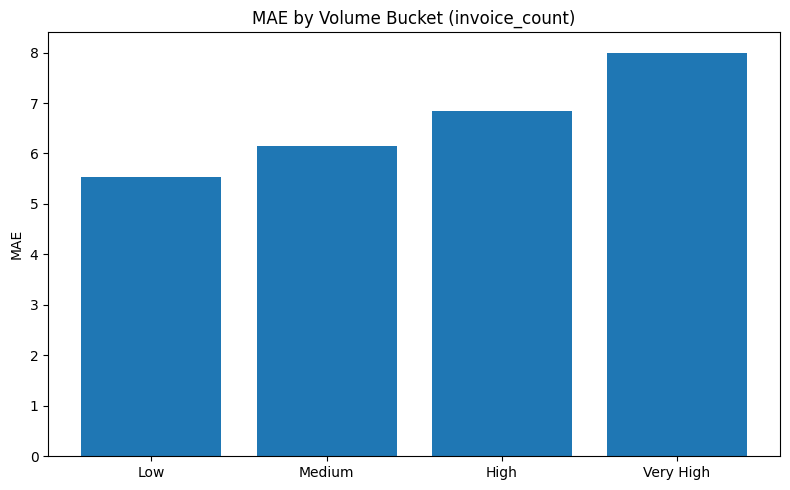

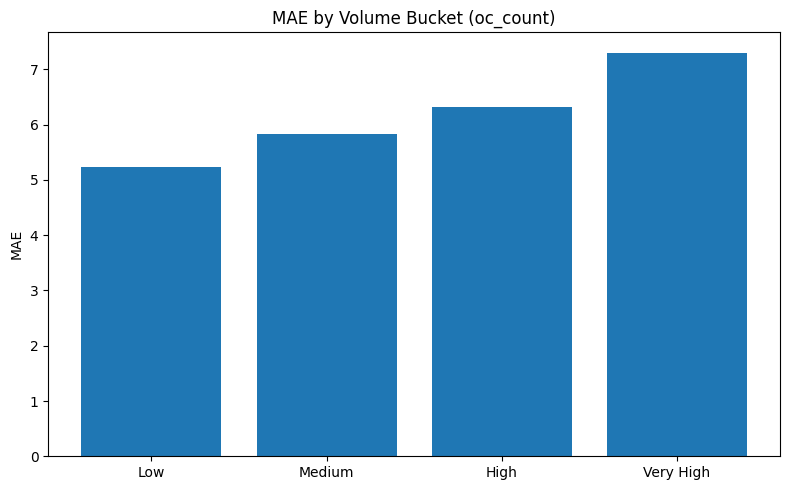

In [9]:
plt.figure(figsize=(8, 5))
plt.bar(invoice_volume["volume_bucket"].astype(str), invoice_volume["mae"])
plt.title("MAE by Volume Bucket (invoice_count)")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(oc_volume["volume_bucket"].astype(str), oc_volume["mae"])
plt.title("MAE by Volume Bucket (oc_count)")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

In [10]:
def bias_summary(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["direction"] = np.where(out["error"] > 0, "Overpredict", "Underpredict")
    return (
        out.groupby("direction")
        .agg(
            n=("direction", "size"),
            mean_abs_error=("abs_error", "mean"),
            mean_signed_error=("error", "mean"),
        )
        .reset_index()
    )

invoice_bias = bias_summary(invoice_df)
oc_bias = bias_summary(oc_df)

display(invoice_bias)
display(oc_bias)

,direction,n,mean_abs_error,mean_signed_error
0,Overpredict,76220,6.583170,6.583170
1,Underpredict,78723,6.666892,-6.666892


,direction,n,mean_abs_error,mean_signed_error
0,Overpredict,74121,6.073868,6.073868
1,Underpredict,80822,6.256135,-6.256135


In [11]:
print("Invoice overall bias:", invoice_df["error"].mean())
print("OC overall bias:", oc_df["error"].mean())

Invoice overall bias: -0.14888408583301901
OC overall bias: -0.3577589572188936


In [12]:
print("Worst invoice_count examples:")
display(invoice_df.sort_values("abs_error", ascending=False).head(10))

print("Worst oc_count examples:")
display(oc_df.sort_values("abs_error", ascending=False).head(10))

Worst invoice_count examples:


,store_id,invoice_date,actual,pred,abs_error,error,month,store_avg_actual,volume_bucket
35442,102098,2022-05-20,233.0,48.262019,184.737981,-184.737981,5,50.536932,Medium
79282,274137,2022-08-11,205.0,56.742705,148.257295,-148.257295,8,52.354749,High
60358,232116,2022-05-10,169.0,37.820283,131.179717,-131.179717,5,61.017192,Very High
6878,86960,2022-08-01,179.0,61.659687,117.340313,-117.340313,8,58.933718,High
8347,88321,2022-09-14,178.0,64.601048,113.398952,-113.398952,9,60.501401,High
4396,84970,2022-07-29,179.0,66.553069,112.446931,-112.446931,7,57.624294,High
36057,102302,2022-03-18,201.0,90.287586,110.712414,-110.712414,3,77.798883,Very High
11349,88666,2022-02-12,167.0,62.789033,104.210967,-104.210967,2,81.638655,Very High
55486,230659,2022-07-26,145.0,43.832407,101.167593,-101.167593,7,43.810056,Medium
104315,611637,2022-04-20,144.0,42.925098,101.074902,-101.074902,4,65.027933,Very High


Worst oc_count examples:


,store_id,invoice_date,actual,pred,abs_error,error,month,store_avg_actual,volume_bucket
35442,102098,2022-05-20,220.0,42.764583,177.235417,-177.235417,5,46.366477,High
60358,232116,2022-05-10,166.0,31.981124,134.018876,-134.018876,5,56.916905,Very High
36057,102302,2022-03-18,200.0,82.705168,117.294832,-117.294832,3,74.343575,Very High
6878,86960,2022-08-01,170.0,54.607964,115.392036,-115.392036,8,55.106628,Very High
4396,84970,2022-07-29,175.0,62.703423,112.296577,-112.296577,7,53.570621,High
60368,232116,2022-05-20,174.0,64.871533,109.128467,-109.128467,5,56.916905,Very High
11349,88666,2022-02-12,160.0,59.902632,100.097368,-100.097368,2,75.599440,Very High
55486,230659,2022-07-26,132.0,33.101064,98.898936,-98.898936,7,36.734637,Medium
104315,611637,2022-04-20,136.0,38.987949,97.012051,-97.012051,4,58.374302,Very High
53639,230652,2022-02-14,153.0,58.576934,94.423066,-94.423066,2,61.211268,Very High


In [13]:
summary = pd.DataFrame({
    "target": ["invoice_count", "oc_count"],
    "overall_mae": [
        invoice_df["abs_error"].mean(),
        oc_df["abs_error"].mean()
    ],
    "overall_bias": [
        invoice_df["error"].mean(),
        oc_df["error"].mean()
    ],
    "worst_month": [
        invoice_month.loc[invoice_month["mae"].idxmax(), "month"],
        oc_month.loc[oc_month["mae"].idxmax(), "month"]
    ],
    "worst_month_mae": [
        invoice_month["mae"].max(),
        oc_month["mae"].max()
    ],
    "worst_store": [
        invoice_store.loc[invoice_store["mae"].idxmax(), "store_id"],
        oc_store.loc[oc_store["mae"].idxmax(), "store_id"]
    ],
    "worst_store_mae": [
        invoice_store["mae"].max(),
        oc_store["mae"].max()
    ],
    "low_volume_mae": [
        invoice_volume.loc[invoice_volume["volume_bucket"] == "Low", "mae"].iloc[0],
        oc_volume.loc[oc_volume["volume_bucket"] == "Low", "mae"].iloc[0]
    ],
    "very_high_volume_mae": [
        invoice_volume.loc[invoice_volume["volume_bucket"] == "Very High", "mae"].iloc[0],
        oc_volume.loc[oc_volume["volume_bucket"] == "Very High", "mae"].iloc[0]
    ],
    "underprediction_count": [
        (invoice_df["error"] < 0).sum(),
        (oc_df["error"] < 0).sum()
    ],
    "overprediction_count": [
        (invoice_df["error"] > 0).sum(),
        (oc_df["error"] > 0).sum()
    ],
})

summary

,target,overall_mae,overall_bias,worst_month,worst_month_mae,worst_store,worst_store_mae,low_volume_mae,very_high_volume_mae,underprediction_count,overprediction_count
0,invoice_count,6.625707,-0.148884,12,8.271317,611652,22.211873,5.532859,8.000328,78723,76220
1,oc_count,6.168943,-0.357759,12,7.687699,231320,11.043956,5.229363,7.305970,80822,74121


Key Findings

1. **Model error is concentrated in a subset of stores rather than evenly distributed across all locations.**  
   For `invoice_count`, store 611652 is a major outlier with much higher MAE than other stores. Both targets show a relatively small group of consistently hard-to-predict stores.

2. **Prediction error is highest in winter, especially in December, for both targets.**  
   December has the highest monthly MAE for both `invoice_count` and `oc_count`, suggesting the current feature set does not fully capture late-year demand shifts, holidays, closures, or winter-specific operational disruptions.

3. **Absolute error increases with store volume for both targets.**  
   MAE rises steadily from low-volume to very-high-volume stores, which suggests that a single global model does not fit all store scales equally well and supports future clustering or segmented modeling.

4. **Both models show a mild underprediction tendency overall, with stronger underprediction for `oc_count`.**  
   Overall mean signed error is negative for both targets, and the effect is stronger for `oc_count`, especially in higher-volume buckets.

5. **The largest failures are extreme underpredictions on spike-demand days.**  
   The worst-case examples are not small random misses; they are unusually large underpredictions on a limited number of days, indicating the model struggles to capture rare demand surges.

## Interpretation

These diagnostics suggest that the current baseline model is reasonably stable overall but has systematic weaknesses. Errors are not evenly distributed: they are higher for certain stores, higher in December, and higher for very-high-volume stores. The strongest failure mode is underprediction on rare demand spikes, which likely reflects missing features such as holidays, closures, promotions, or local operational factors.

This supports the next sprint directions: (1) evaluating segmented or clustered modeling, (2) testing whether upgraded weather and calendar features reduce winter-period error, and (3) adding calibrated prediction intervals to better communicate uncertainty on volatile days.

In [1]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

print("ROOT:", ROOT)

ROOT: /Users/harshini/GenAI-Weather-Based-Store-Analytics


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.dataset import DatasetBuilder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.inspection import permutation_importance

TARGET = "invoice_count"   # change to "oc_count" later

builder = DatasetBuilder(cutoff="2022-01-01")
train_df = builder.train.copy()
valid_df = builder.valid.copy()

print("train:", train_df.shape)
print("valid:", valid_df.shape)
print("columns:", len(train_df.columns))

train: (603838, 42)
valid: (152866, 42)
columns: 42


In [3]:
def build_feature_sets_current(df: pd.DataFrame):
    leakage_cols = ["invoice_count", "oc_count", "fleet_oc_count"]
    non_feature_cols = ["invoice_date"]

    feature_cols = [c for c in df.columns if c not in leakage_cols + non_feature_cols]
    categorical_cols = [c for c in ["store_id"] if c in feature_cols]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    return feature_cols, categorical_cols, numeric_cols

feature_cols, categorical_cols, numeric_cols = build_feature_sets_current(train_df)

print("feature count:", len(feature_cols))
print("categorical:", categorical_cols)
print("numeric count:", len(numeric_cols))
print("first 20 features:", feature_cols[:20])

feature count: 38
categorical: ['store_id']
numeric count: 37
first 20 features: ['store_id', 'inv_lag_1', 'inv_lag_7', 'inv_rollmean_7', 'inv_rollmean_14', 'inv_rollmean_28', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wspd', 'tavg_lag1', 'tavg_lag3', 'tavg_lag7', 'tmin_lag1', 'tmin_lag3', 'tmin_lag7', 'tmax_lag1', 'tmax_lag3']


In [4]:
weather_keywords = [
    "tavg", "tmin", "tmax", "prcp", "snow", "wspd",
    "rain", "freezing", "heat", "cold", "weather"
]

def is_weather_feature(col: str) -> bool:
    c = col.lower()
    return any(k in c for k in weather_keywords)

weather_cols = [c for c in feature_cols if is_weather_feature(c)]
non_weather_cols = [c for c in feature_cols if c not in weather_cols]

print("weather_cols:", len(weather_cols))
print("non_weather_cols:", len(non_weather_cols))
print("weather examples:", weather_cols[:20])

weather_cols: 29
non_weather_cols: 9
weather examples: ['tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wspd', 'tavg_lag1', 'tavg_lag3', 'tavg_lag7', 'tmin_lag1', 'tmin_lag3', 'tmin_lag7', 'tmax_lag1', 'tmax_lag3', 'tmax_lag7', 'prcp_lag1', 'prcp_lag3', 'prcp_lag7', 'snow_lag1', 'snow_lag3']


In [5]:
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def train_hgb_pipeline(train_df, valid_df, target, feature_cols, categorical_cols):
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    X_train = train_df[feature_cols].copy()
    y_train = train_df[target].astype(float).copy()

    X_valid = valid_df[feature_cols].copy()
    y_valid = valid_df[target].astype(float).copy()

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", make_ohe(), [c for c in categorical_cols if c in feature_cols]),
            ("num", SimpleImputer(strategy="median"), numeric_cols),
        ],
        remainder="drop",
    )

    model = HistGradientBoostingRegressor(
        random_state=42,
        learning_rate=0.05,
        max_iter=400,
        max_depth=None,
    )

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model),
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_valid)
    mae = mean_absolute_error(y_valid, pred)

    return pipe, mae, X_valid, y_valid

In [6]:
full_pipe, full_mae, X_valid_full, y_valid_full = train_hgb_pipeline(
    train_df=train_df,
    valid_df=valid_df,
    target=TARGET,
    feature_cols=feature_cols,
    categorical_cols=categorical_cols,
)

print("Full model MAE:", full_mae)

Full model MAE: 6.650021276425403


In [7]:
categorical_cols_no_weather = [c for c in categorical_cols if c in non_weather_cols]

no_weather_pipe, no_weather_mae, X_valid_no_weather, y_valid_no_weather = train_hgb_pipeline(
    train_df=train_df,
    valid_df=valid_df,
    target=TARGET,
    feature_cols=non_weather_cols,
    categorical_cols=categorical_cols_no_weather,
)

print("No-weather model MAE:", no_weather_mae)
print("MAE delta (no_weather - full):", no_weather_mae - full_mae)

No-weather model MAE: 6.799036235189877
MAE delta (no_weather - full): 0.14901495876447424


In [8]:
perm = permutation_importance(
    full_pipe,
    X_valid_full,
    y_valid_full,
    n_repeats=5,
    random_state=42,
    scoring="neg_mean_absolute_error",
)

importance_df = pd.DataFrame({
    "feature": X_valid_full.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

importance_df.head(20)

,feature,importance_mean,importance_std
35,dow,3.399890,0.007374
3,inv_rollmean_7,2.012346,0.010519
5,inv_rollmean_28,0.869119,0.006067
1,inv_lag_1,0.795763,0.007445
4,inv_rollmean_14,0.689292,0.008279
2,inv_lag_7,0.303076,0.001811
8,tmax,0.214875,0.004105
9,prcp,0.209623,0.003082
0,store_id,0.139851,0.002654
36,month,0.137072,0.002318


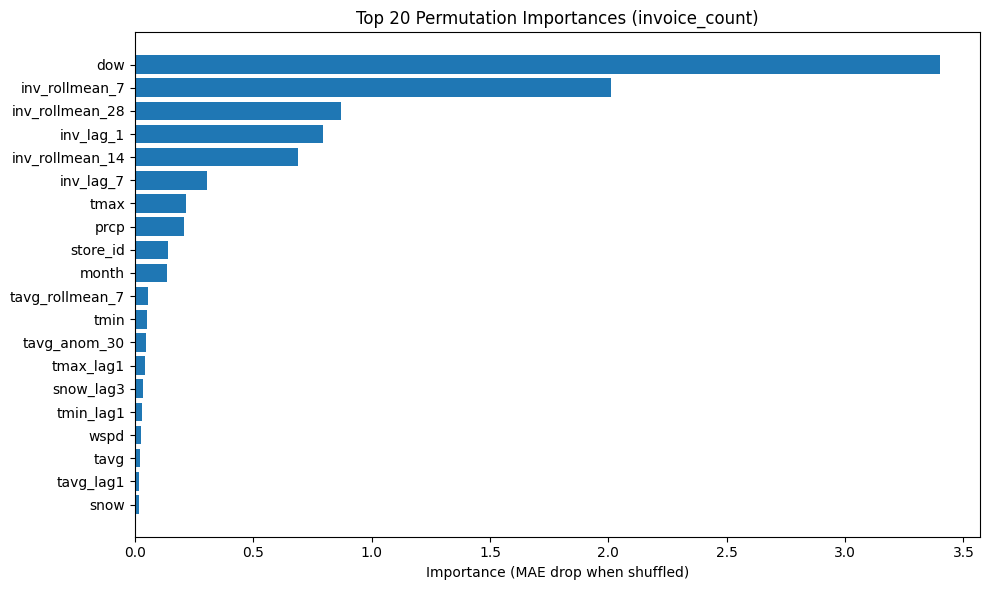

In [9]:
top20 = importance_df.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20["feature"][::-1], top20["importance_mean"][::-1])
plt.title(f"Top 20 Permutation Importances ({TARGET})")
plt.xlabel("Importance (MAE drop when shuffled)")
plt.tight_layout()
plt.show()

In [10]:
importance_df["is_weather"] = importance_df["feature"].apply(is_weather_feature)

weather_summary = (
    importance_df.groupby("is_weather", as_index=False)["importance_mean"]
    .sum()
    .sort_values("importance_mean", ascending=False)
)

weather_summary

,is_weather,importance_mean
0,False,8.35742
1,True,0.86352


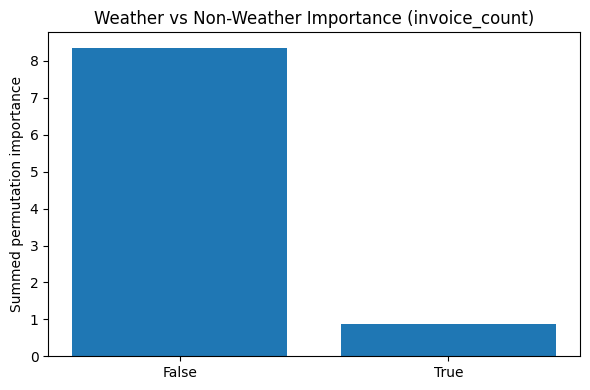

In [11]:
plt.figure(figsize=(6, 4))
plt.bar(weather_summary["is_weather"].astype(str), weather_summary["importance_mean"])
plt.title(f"Weather vs Non-Weather Importance ({TARGET})")
plt.ylabel("Summed permutation importance")
plt.tight_layout()
plt.show()

## Feature Importance & Weather Signal Stability findings

1. **The current baseline is driven primarily by calendar structure and recent demand history.**  
   The strongest features are day-of-week and recent demand-memory features such as 7-day and 28-day rolling means and lagged invoice counts. This shows that the model’s main predictive power comes from regular traffic patterns and short-term demand momentum.

2. **Weather features contribute measurable value, but they are secondary to baseline demand signals.**  
   Comparing the full model to a no-weather version shows that removing weather increases validation MAE from 6.650 to 6.799, a degradation of about 0.149 MAE. This means weather improves prediction quality, but the gain is modest rather than dominant.

3. **Weather effects appear as adjustment signals rather than primary drivers.**  
   Several weather variables appear in the top permutation importance features, including temperature, precipitation, snow, wind speed, and recent weather lags. However, they rank below calendar and demand-memory features, indicating that weather mainly fine-tunes the baseline forecast.

4. **The project’s business story should be framed as weather-adjusted demand prediction, not weather-only prediction.**  
   The evidence suggests that store traffic is mostly explained by recurring demand structure, while weather provides an additional lift or drag around that baseline.

In [12]:
TARGET_OC = "oc_count"
print("Now analyzing:", TARGET_OC)

Now analyzing: oc_count


In [13]:
feature_cols_oc, categorical_cols_oc, numeric_cols_oc = build_feature_sets_current(train_df)

print("feature count (oc):", len(feature_cols_oc))
print("categorical (oc):", categorical_cols_oc)
print("numeric count (oc):", len(numeric_cols_oc))
print("first 20 features (oc):", feature_cols_oc[:20])

feature count (oc): 38
categorical (oc): ['store_id']
numeric count (oc): 37
first 20 features (oc): ['store_id', 'inv_lag_1', 'inv_lag_7', 'inv_rollmean_7', 'inv_rollmean_14', 'inv_rollmean_28', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wspd', 'tavg_lag1', 'tavg_lag3', 'tavg_lag7', 'tmin_lag1', 'tmin_lag3', 'tmin_lag7', 'tmax_lag1', 'tmax_lag3']


In [14]:
weather_cols_oc = [c for c in feature_cols_oc if is_weather_feature(c)]
non_weather_cols_oc = [c for c in feature_cols_oc if c not in weather_cols_oc]

print("weather_cols (oc):", len(weather_cols_oc))
print("non_weather_cols (oc):", len(non_weather_cols_oc))
print("weather examples (oc):", weather_cols_oc[:20])

weather_cols (oc): 29
non_weather_cols (oc): 9
weather examples (oc): ['tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wspd', 'tavg_lag1', 'tavg_lag3', 'tavg_lag7', 'tmin_lag1', 'tmin_lag3', 'tmin_lag7', 'tmax_lag1', 'tmax_lag3', 'tmax_lag7', 'prcp_lag1', 'prcp_lag3', 'prcp_lag7', 'snow_lag1', 'snow_lag3']


In [15]:
full_pipe_oc, full_mae_oc, X_valid_full_oc, y_valid_full_oc = train_hgb_pipeline(
    train_df=train_df,
    valid_df=valid_df,
    target=TARGET_OC,
    feature_cols=feature_cols_oc,
    categorical_cols=categorical_cols_oc,
)

print("Full model MAE (oc):", full_mae_oc)

Full model MAE (oc): 6.177693280824069


In [16]:
categorical_cols_no_weather_oc = [c for c in categorical_cols_oc if c in non_weather_cols_oc]

no_weather_pipe_oc, no_weather_mae_oc, X_valid_no_weather_oc, y_valid_no_weather_oc = train_hgb_pipeline(
    train_df=train_df,
    valid_df=valid_df,
    target=TARGET_OC,
    feature_cols=non_weather_cols_oc,
    categorical_cols=categorical_cols_no_weather_oc,
)

print("No-weather model MAE (oc):", no_weather_mae_oc)
print("MAE delta (no_weather - full) (oc):", no_weather_mae_oc - full_mae_oc)

No-weather model MAE (oc): 6.332634711917265
MAE delta (no_weather - full) (oc): 0.1549414310931958


In [17]:
perm_oc = permutation_importance(
    full_pipe_oc,
    X_valid_full_oc,
    y_valid_full_oc,
    n_repeats=5,
    random_state=42,
    scoring="neg_mean_absolute_error",
)

importance_df_oc = pd.DataFrame({
    "feature": X_valid_full_oc.columns,
    "importance_mean": perm_oc.importances_mean,
    "importance_std": perm_oc.importances_std,
}).sort_values("importance_mean", ascending=False)

importance_df_oc.head(20)

,feature,importance_mean,importance_std
35,dow,2.741457,0.008904
3,inv_rollmean_7,1.570178,0.007321
0,store_id,1.103201,0.003898
5,inv_rollmean_28,0.790233,0.004545
1,inv_lag_1,0.590548,0.003444
4,inv_rollmean_14,0.551910,0.007128
2,inv_lag_7,0.420237,0.003014
9,prcp,0.205872,0.004194
36,month,0.190557,0.002720
8,tmax,0.124907,0.002142


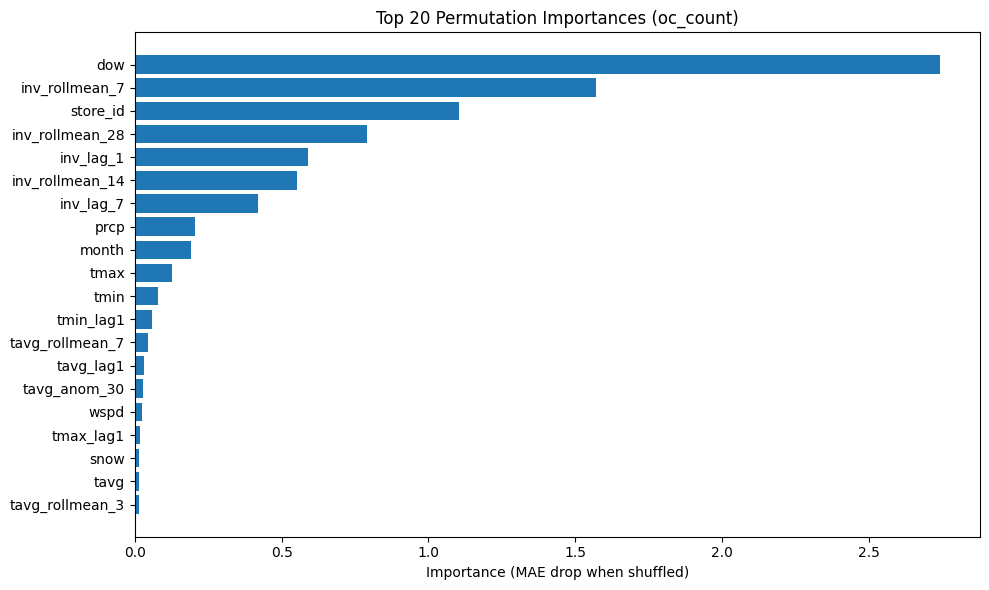

In [18]:
top20_oc = importance_df_oc.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20_oc["feature"][::-1], top20_oc["importance_mean"][::-1])
plt.title("Top 20 Permutation Importances (oc_count)")
plt.xlabel("Importance (MAE drop when shuffled)")
plt.tight_layout()
plt.show()

In [19]:
importance_df_oc["is_weather"] = importance_df_oc["feature"].apply(is_weather_feature)

weather_summary_oc = (
    importance_df_oc.groupby("is_weather", as_index=False)["importance_mean"]
    .sum()
    .sort_values("importance_mean", ascending=False)
)

weather_summary_oc

,is_weather,importance_mean
0,False,7.966657
1,True,0.707401


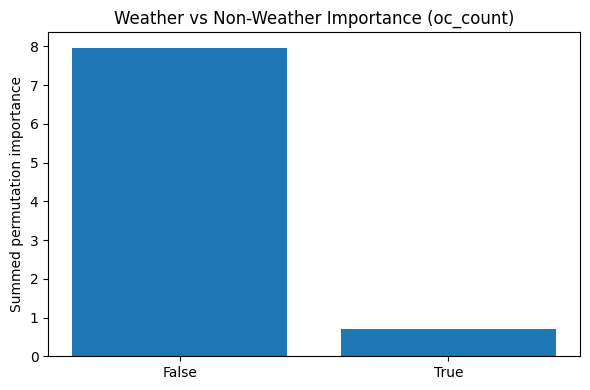

In [20]:
plt.figure(figsize=(6, 4))
plt.bar(weather_summary_oc["is_weather"].astype(str), weather_summary_oc["importance_mean"])
plt.title("Weather vs Non-Weather Importance (oc_count)")
plt.ylabel("Summed permutation importance")
plt.tight_layout()
plt.show()

In [21]:
comparison_ = pd.DataFrame({
    "target": ["invoice_count", "oc_count"],
    "full_mae": [full_mae, full_mae_oc],
    "no_weather_mae": [no_weather_mae, no_weather_mae_oc],
})

comparison_["mae_delta_no_weather_minus_full"] = (
    comparison_["no_weather_mae"] - comparison_["full_mae"]
)

comparison_

,target,full_mae,no_weather_mae,mae_delta_no_weather_minus_full
0,invoice_count,6.650021,6.799036,0.149015
1,oc_count,6.177693,6.332635,0.154941


## Findings — oc_count

1. **Demand memory and calendar structure remain the dominant predictive signals.**  
   The most important features include day-of-week and recent demand history such as 7-day and 28-day rolling invoice averages and lagged demand signals. This indicates that oil-change activity follows strong recurring demand patterns.

2. **Weather features provide measurable but secondary predictive value.**  
   Removing weather features increases validation MAE from 6.178 to 6.333, a degradation of approximately 0.155 MAE. This is very similar to the effect observed for invoice_count.

3. **Weather acts as an adjustment signal rather than the primary driver of demand.**  
   Weather variables such as precipitation, temperature, snow, and wind appear among the top 20 features but rank below calendar and demand-memory signals.

4. **Weather impact is consistent across both targets.**  
   The magnitude of performance degradation when removing weather features is nearly identical for invoice_count and oc_count, suggesting that weather influences both visit counts and oil-change transactions similarly.